Includes visualizations to capture trends in crime 

In [12]:
# Imports and setup
import plotnine
from plotnine.data import economics
from plotnine import ggplot, aes, geom_line, labs
import pandas as pd
import json

In [3]:
with open("data/arrest_response.json") as f:
    raw_file = json.load(f)

arrests = pd.json_normalize(raw_file['rates'])
arrests = arrests.transpose().reset_index().rename(columns={0: "Arrest Rate", "index": "Month"})
arrests['Month'] = arrests['Month'].str.replace('United States Arrests.', '')
arrests.set_index("Month", inplace=True)

In [4]:
with open("data/violent_response.json") as f:
    raw_file = json.load(f)

violent = pd.json_normalize(raw_file['offenses']['rates']['United States Offenses'])
violent = violent.transpose().reset_index().rename(columns={0: "Violent Crime Rate", "index": "Month"})
violent['Month'] = violent['Month'].str.replace('United States Offenses.', '')
violent.set_index('Month', inplace=True)

In [5]:
with open("data/property_response.json") as f:
    raw_file = json.load(f)

property = pd.json_normalize(raw_file['offenses']['rates']['United States Offenses'])
property = property.transpose().reset_index().rename(columns={0: "Property Crime Rate", "index": "Month"})
property['Month'] = property['Month'].str.replace('United States Offenses.', '')
property.set_index('Month', inplace=True)

In [6]:
with open("data/hate_response.json") as f:
    raw_file = json.load(f)

hate = pd.json_normalize(raw_file['rates']['United States Incidents'])
hate = hate.transpose().reset_index().rename(columns={0: "Hate Crime Incident Rate", "index": "Month"})
hate['Month'] = hate['Month'].str.replace('United States Incidents.', '')
hate.set_index('Month', inplace=True)
hate

,Hate Crime Incident Rate
Month,
01-2020,0.19
01-2021,0.29
01-2022,0.23
01-2023,0.26
01-2024,0.25
...,...
12-2021,0.30
12-2022,0.27
12-2023,0.33


In [7]:
crime_stats = pd.concat([arrests, hate, property, violent], axis=1, join='outer')
crime_stats = crime_stats.reset_index()
crime_stats["Month"] = pd.to_datetime(crime_stats["Month"], format="%m-%Y")
crime_stats

,Month,Arrest Rate,Hate Crime Incident Rate,Property Crime Rate,Violent Crime Rate
0,2020-01-01,239.71,0.19,162.86,29.02
1,2021-01-01,159.98,0.29,145.00,28.47
2,2022-01-01,160.11,0.23,155.76,30.50
3,2023-01-01,179.89,0.26,161.60,31.60
4,2024-01-01,167.80,0.25,146.42,27.79
...,...,...,...,...,...
67,2021-12-01,160.94,0.30,161.21,29.43
68,2022-12-01,163.18,0.27,202.20,38.13
69,2023-12-01,175.29,0.33,181.67,33.97
70,2024-12-01,165.04,0.25,158.18,30.24


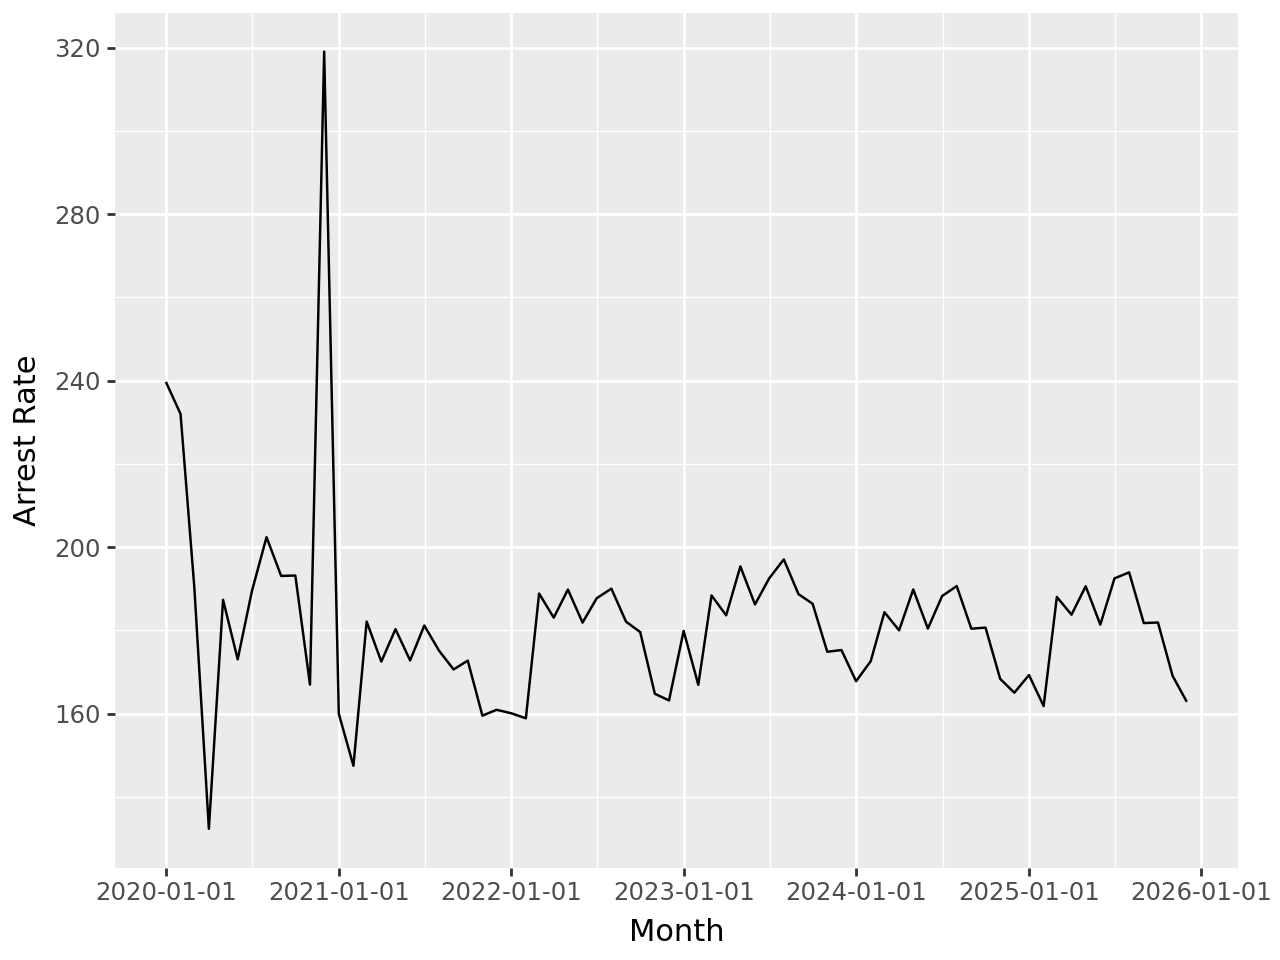

In [8]:
(
    ggplot(crime_stats)+
        aes(x="Month", y="Arrest Rate")+
        geom_line()
)

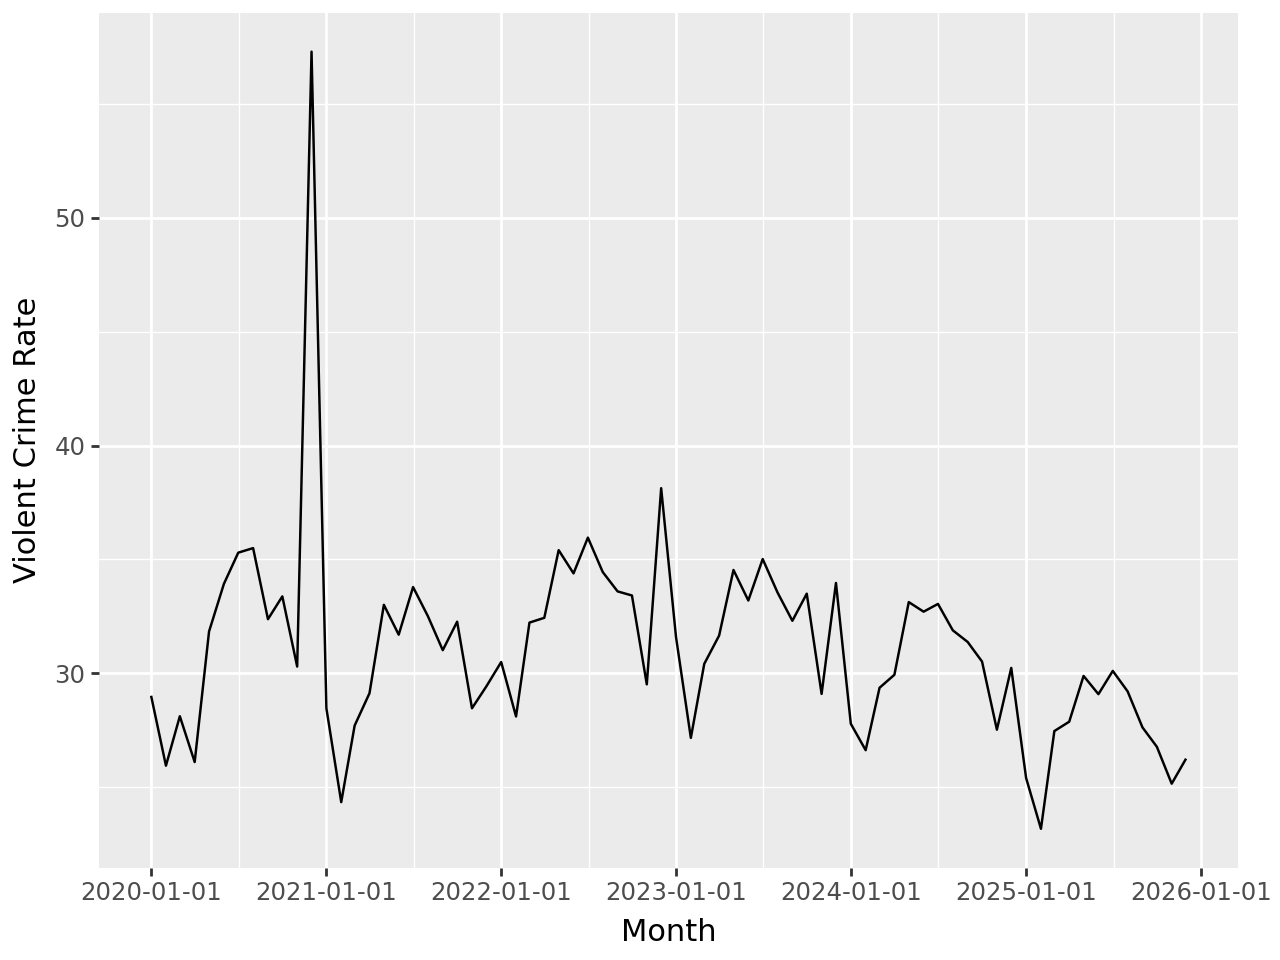

In [9]:
(
    ggplot(crime_stats)+
        aes(x="Month", y="Violent Crime Rate")+
        geom_line()
)

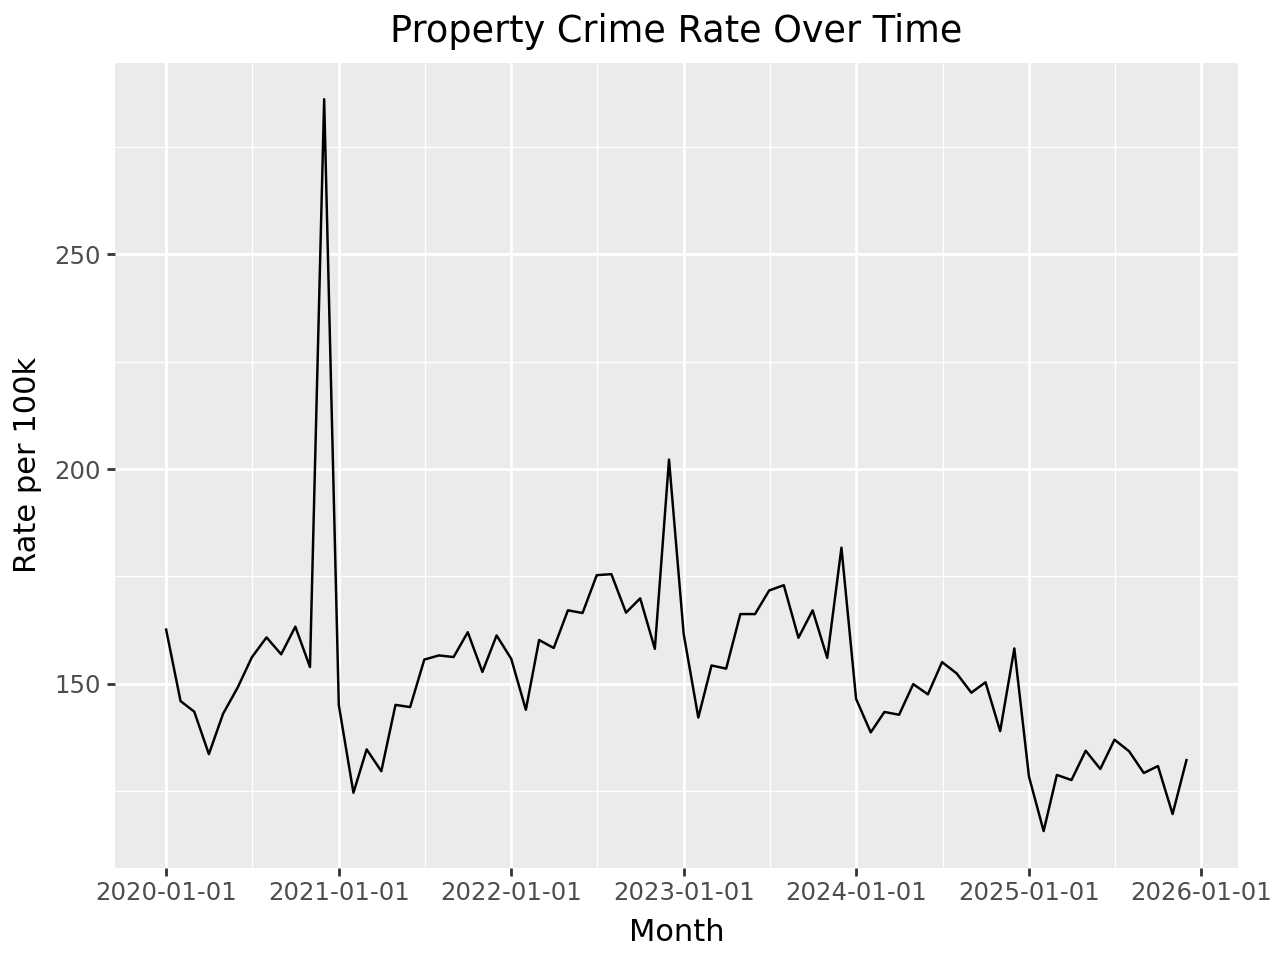

In [13]:
plot=(
    ggplot(crime_stats)+
        aes(x="Month", y="Property Crime Rate")+
        geom_line()
)
plot + labs(title="Property Crime Rate Over Time", x="Month", y="Rate per 100k")

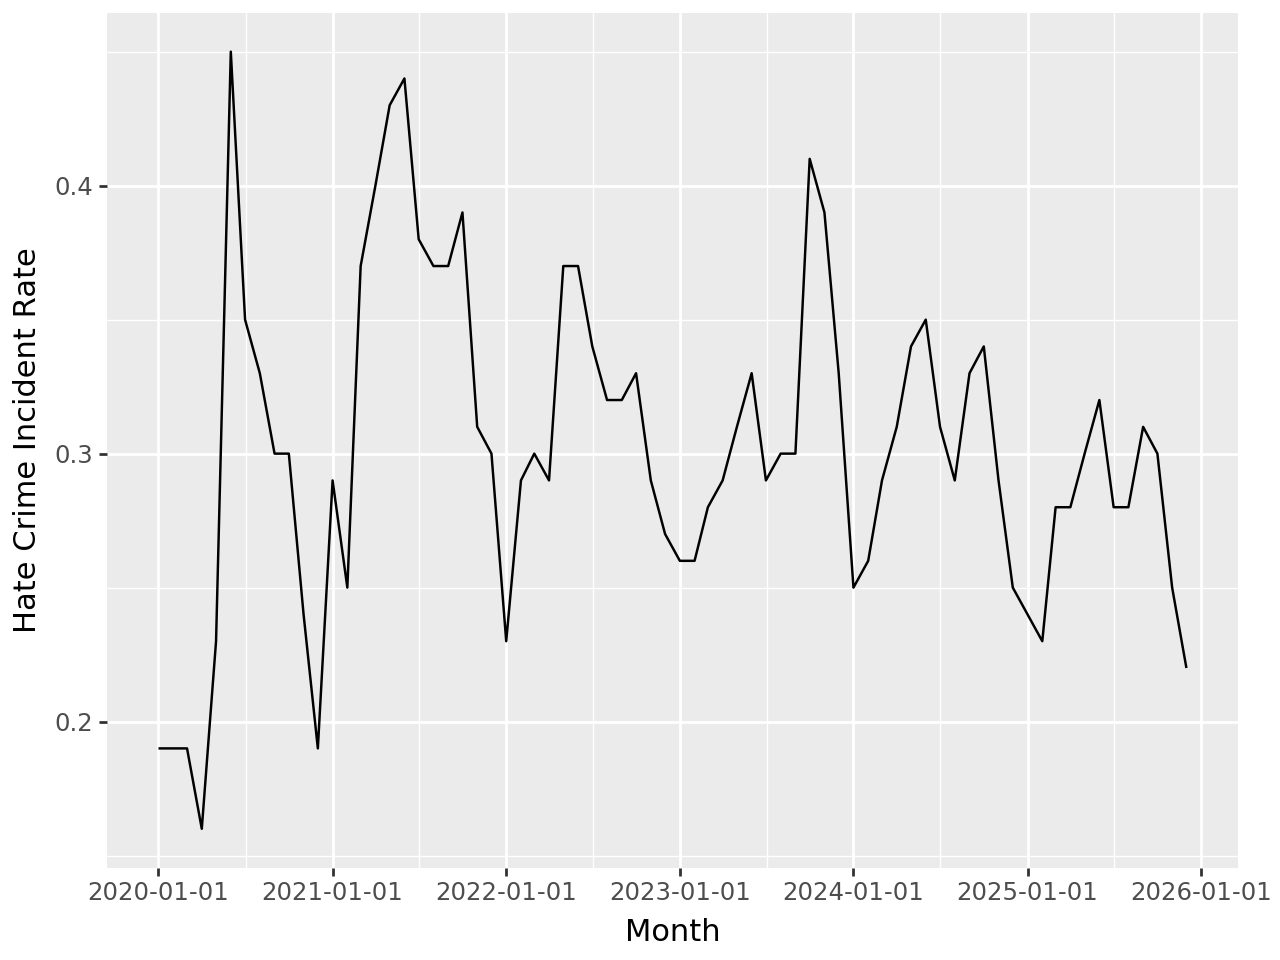

In [ ]:
(
    ggplot(crime_stats)+
        aes(x="Month", y="Hate Crime Incident Rate")+
        geom_line()
)